In [10]:
import numpy as np
from numpy.polynomial.legendre import Legendre

def generate_legendre_maps(
    X, M, m, coef_scale=1.0,
    perc_min=0.5, perc_max=99.5,
    clip=True, rng=None
):
    if rng is None:
        rng = np.random.default_rng()

    X = np.asarray(X)
    N, D = X.shape

    mappings = []

    for _ in range(M):
        # Step 1: random projection direction
        u = rng.normal(size=D)
        u /= np.linalg.norm(u)

        # Step 2: project data along this direction
        z = X @ u

        # Step 3: compute stable percentile bounds
        a = np.percentile(z, perc_min)
        b = np.percentile(z, perc_max)
        if a == b:
            a, b = -1.0, 1.0

        # Step 4: random Legendre coefficients
        coef = rng.normal(scale=coef_scale, size=m+1)

        # Step 5: build Legendre polynomial with domain mapping
        P = Legendre(coef, domain=[a, b], window=[-1,1])

        # Step 6: mapping function
        def make_map(u_local, P_local, a_local, b_local, coef_local):
            def f(x):
                x = np.asarray(x)
                zz = x @ u_local
                if clip:
                    zz = np.clip(zz, a_local, b_local)
                return P_local(zz)
            # ⬇ attach parameters explicitly ⬇
            f.u = u_local
            f.a = a_local
            f.b = b_local
            f.P = P_local
            f.coef = coef_local
            return f

        mappings.append(make_map(u, P, a, b, coef))

    if M == 1:
        return mappings[0]
    return mappings


In [11]:
N = 5000
D = 50
X = np.random.randn(N, D)

# generate 5 different degree-6 Legendre nonlinear projections
maps = generate_legendre_maps(X, M=1, m=3, coef_scale=0.5)

# evaluate the first mapping
y = maps(X)   # shape (5000,)

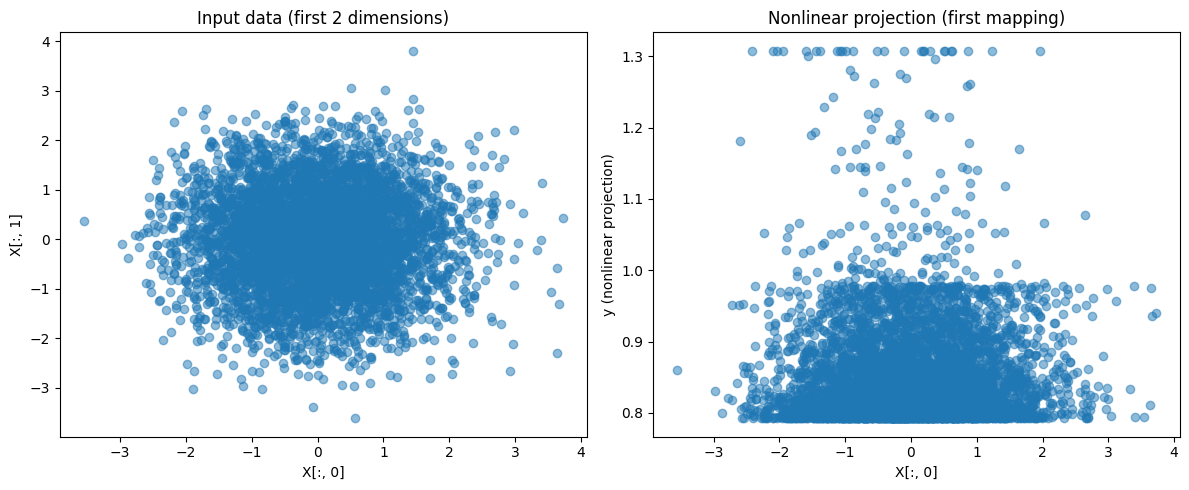

In [12]:
#plot the input data and one of the nonlinear projections
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.title("Input data (first 2 dimensions)")
plt.scatter(X[:, 0], X[:, 1], alpha=0.5)
plt.xlabel("X[:, 0]")
plt.ylabel("X[:, 1]")
plt.subplot(1, 2, 2)
plt.title("Nonlinear projection (first mapping)")
plt.scatter(X[:, 0], y, alpha=0.5)
plt.xlabel("X[:, 0]")
plt.ylabel("y (nonlinear projection)")
plt.tight_layout()
plt.show()

eps=0.01, k*=3
eps=0.001, k*=6
eps=0.0001, k*=10


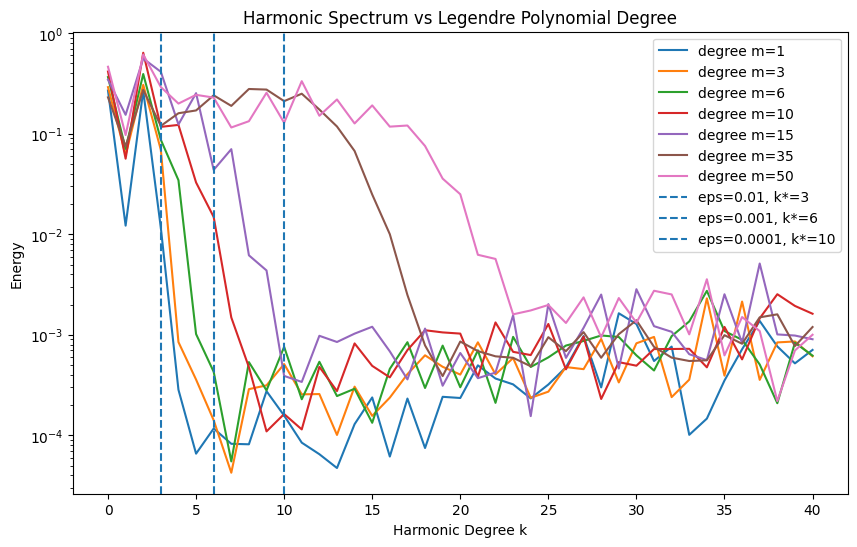

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.polynomial.legendre import legval

def estimate_spectrum_from_map(f, u, Kmax=40, D=100, N_samples=20000, rng=None):
    """
    Estimate harmonic energy spectrum for mapping f(x).
    f : mapping function from your generate_legendre_maps
    u : the projection direction associated with f
    """
    if rng is None:
        rng = np.random.default_rng()

    # Sample points uniformly on sphere (Gaussian + normalize)
    X = rng.normal(size=(N_samples, D))
    X /= np.linalg.norm(X, axis=1, keepdims=True)

    # compute s = u · x
    s = X @ u

    # evaluate teacher
    y = f(X)

    E = np.zeros(Kmax+1)

    for k in range(Kmax+1):
        # Legendre P_k(s)
        Pk = legval(s, [0]*k + [1])

        ck = (2*k+1)/2 * np.mean(y * Pk)
        E[k] = ck**2

    return E


def spectrum_for_degree(X, m, num_maps=10, Kmax=40, D=None, rng=None):
    if rng is None:
        rng = np.random.default_rng()

    if D is None:
        D = X.shape[1]

    spectra = []

    # Generate num_maps random mappings of degree m
    maps = generate_legendre_maps(X, M=num_maps, m=m, coef_scale=1.0, rng=rng)

    for f in maps:
        # Extract closure variable u (we stored it inside make_map)
        u = f.u

        E = estimate_spectrum_from_map(f, u, Kmax=Kmax, D=D, rng=rng)
        spectra.append(E)

    return np.array(spectra)  # shape = (num_maps, Kmax+1)

def bietti_cutoff(D, eps=1e-3):
    """
    Compute approximate Bietti cutoff k* (spherical harmonic degree) 
    for ReLU NTK in dimension D.
    Uses asymptotic eigenvalues mu_k ∝ k^{-p} with p = D - 1.
    """
    p = D - 1

    # Solve mu_k = eps  →  C_p * k^{-p} = eps
    # Drop C_p (constant) since cutoff relative to scale
    # => k^p = 1/eps  =>  k = eps^{-1/p}
    k_star = eps ** (-1 / p)
    return int(np.round(k_star))


# ---- Run experiment ----
X = np.random.randn(5000, 5)
D = X.shape[1]

degrees = [1, 3, 6, 10, 15, 35, 50]
Kmax = 40
num_maps = 10

plt.figure(figsize=(10,6))

for m in degrees:
    S = spectrum_for_degree(X, m, num_maps=num_maps, Kmax=Kmax)
    E_mean = S.mean(axis=0)

    plt.plot(np.arange(Kmax+1), E_mean, label=f"degree m={m}")
    
for eps in [1e-2, 1e-3, 1e-4]:
    k_star = bietti_cutoff(D, eps)
    print(f"eps={eps}, k*={k_star}")
    plt.axvline(k_star, linestyle='--', label=f"eps={eps}, k*={k_star}")

plt.yscale("log")
plt.xlabel("Harmonic Degree k")
plt.ylabel("Energy")
plt.legend()
plt.title("Harmonic Spectrum vs Legendre Polynomial Degree")
plt.show()
